In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.formula.api import mixedlm

In [3]:
# load dataset

In [8]:
df = pd.read_csv("strawberry.csv", sep=";")

df.head()

,participant_id,week,group,assigned_strawberries_g,actual_strawberries_g,study_hours,sleep_hours,stress_level,exam_score
0,P01,1,100g,100,98,12,8.1,3,71
1,P01,2,100g,100,100,13,8.0,3,73
2,P01,3,100g,100,95,14,7.9,4,74
3,P01,4,100g,100,102,14,8.2,3,76
4,P01,5,100g,100,100,15,8.0,3,78


In [9]:
df.groupby("group")["exam_score"].describe()

,count,mean,std,min,25%,50%,75%,max
group,,,,,,,,
0g,24.0,78.208333,9.231229,63.0,68.75,81.5,86.00,90.0
100g,16.0,75.250000,4.090640,68.0,72.50,75.5,78.25,82.0
200g,24.0,71.416667,6.723849,59.0,68.25,71.5,76.00,84.0
50g,16.0,64.625000,3.442383,58.0,62.75,64.5,67.25,70.0


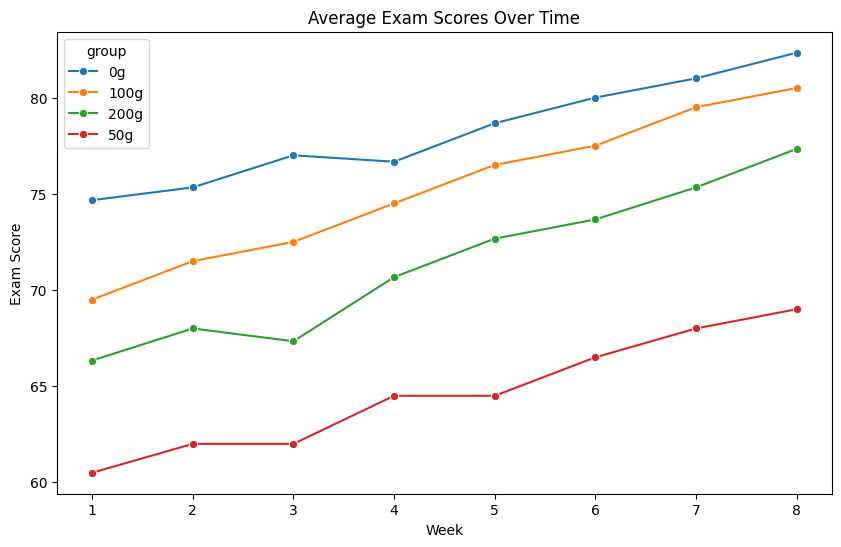

In [10]:
mean_scores = (
    df.groupby(["week", "group"])["exam_score"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(10,6))

sns.lineplot(
    data=mean_scores,
    x="week",
    y="exam_score",
    hue="group",
    marker="o"
)

plt.title("Average Exam Scores Over Time")
plt.ylabel("Exam Score")
plt.xlabel("Week")
plt.show()

In [12]:
model = mixedlm(
    "exam_score ~ week + actual_strawberries_g + study_hours + stress_level",
    data=df,
    groups=df["participant_id"]
)

result = model.fit()

print(result.summary())

             Mixed Linear Model Regression Results
Model:                MixedLM   Dependent Variable:   exam_score
No. Observations:     80        Method:               REML      
No. Groups:           10        Scale:                0.9903    
Min. group size:      8         Log-Likelihood:       -141.1486 
Max. group size:      8         Converged:            Yes       
Mean group size:      8.0                                       
----------------------------------------------------------------
                      Coef.  Std.Err.   z    P>|z| [0.025 0.975]
----------------------------------------------------------------
Intercept             59.978    4.018 14.926 0.000 52.102 67.853
week                   0.460    0.156  2.951 0.003  0.154  0.766
actual_strawberries_g -0.006    0.011 -0.573 0.566 -0.028  0.015
study_hours            1.186    0.302  3.928 0.000  0.594  1.778
stress_level          -1.158    0.238 -4.870 0.000 -1.624 -0.692
Group Var             18.500   10.468  